In [1]:
from sklearn.model_selection import train_test_split

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("data.csv")
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [ ]:
# data = Pipeline([
#     ('scalar', StandardScaler()),
#     ('logistic',LogisticRegression(max_iter=100))
# ])

In [37]:
data.drop(['id', 'Unnamed: 32'], axis=1, inplace=True, errors='ignore')
data['diagnosis'] = data['diagnosis'].map({'M':1, 'B': 0})

x = data.drop('diagnosis', axis=1)
x = x.fillna(x.mean())
y = data['diagnosis']

x = x.apply(pd.to_numeric, errors='coerce')
x = x.fillna(x.mean())

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)
model.score(X_test_scaled, y_test)

0.9736842105263158

In [38]:
import plotly.express as px
px.histogram(data_frame = data, x='diagnosis')

In [39]:
px.histogram(data_frame = data, x='area_mean')

In [40]:
px.histogram(data_frame=data, x='perimeter_mean', color='diagnosis')

In [41]:
px.histogram(data_frame=data,x='smoothness_mean', color='diagnosis')

In [42]:
px.histogram(data_frame=data, x='texture_mean', color='diagnosis', color_discrete_sequence= ['#0523EC',
                                                                                             '#7513BA'])

In [43]:
px.scatter(data_frame=data, x = 'symmetry_worst', color='diagnosis')

In [44]:
px.scatter(data_frame= data, x='fractal_dimension_worst', color = 'diagnosis')

In [45]:
data.isna().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [46]:
px.scatter(data_frame=data, x='concavity_worst', color='diagnosis')

In [47]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

In [ ]:
# EDA  and logistic regression 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
predictions = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, predictions)
cm

array([[70,  1],
       [ 2, 41]])

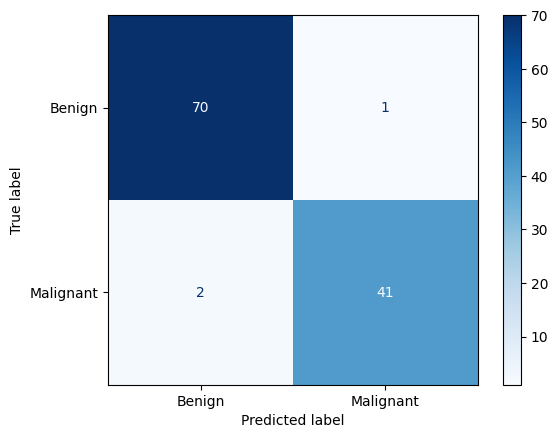

In [53]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign','Malignant'])
disp.plot(cmap='Blues')
plt.show()